<a href="https://colab.research.google.com/github/AlmasMalik66/DataScience-AI-Assignments/blob/main/Week9/Assignment9_Neural_Networks_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step1: Import Libraries**

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, classification_report

**STEP 2: Load Cleaned Dataset**

In [7]:
df = pd.read_csv("FakeNewsDetection_Cleaned.csv")
df.head()

,title,text,subject,date,text_length
0,HERE’S HOW ONE MAN Stopped Huge Riot Ready To ...,Watch the video below and you ll understand th...,left-news,"Nov 12, 2016",136
1,"DISGUSTING VIDEO EMERGES of LIBERAL ACTOR, and...",Liberal actor and close friend of Hillary Clin...,left-news,"Oct 12, 2017",2774
2,Patriot Can’t Wait To Go Fight Gubmint With O...,You know that feeling when you want to overthr...,News,"January 4, 2016",2733
3,Here’s How The Trump Campaign Can Still Win A...,"Dubbed the missing white voters, Nate Silver...",News,"September 30, 2016",3590
4,BRITISH TV PERSONALITY: Don’t Blame Trump For ...,He [Obama] makes me want to wrap a suicide ve...,politics,"Dec 9, 2015",5809


In [12]:
df_fake = pd.read_csv("Fake.csv", on_bad_lines='skip')
df_true = pd.read_csv("True.csv", on_bad_lines='skip')

df_fake['label'] = 1
df_true['label'] = 0

df_full = pd.concat([df_fake, df_true], ignore_index=True)

df_full['combined_text'] = df_full['title'] + " " + df_full['text']
df_full = df_full.dropna(subset=['combined_text'])

df_full.head()


,title,text,subject,date,label,combined_text
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1,Donald Trump Sends Out Embarrassing New Year’...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1,Drunk Bragging Trump Staffer Started Russian ...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1,Sheriff David Clarke Becomes An Internet Joke...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1,Trump Is So Obsessed He Even Has Obama’s Name...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1,Pope Francis Just Called Out Donald Trump Dur...


**Step 3: Split the Data (Train/Test Split)**

In [15]:
X = df_full['combined_text']
y = df_full['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Step 4: Convert Text to TF-IDF Vectors**

In [16]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


# **CLASS TASK: Build a Simple ANN**

**Step 5: Build the ANN Model**

In [26]:
model = Sequential()
model.add(Dense(16, activation='relu', input_shape=(X_train_tfidf.shape[1],)))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │        80,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,161 (313.13 KB)

 Trainable params: 80,161 (313.13 KB)

 Non-trainable params: 0 (0.00 B)

**Step 6: Train the ANN**

In [28]:
history = model.fit(
    X_train_tfidf.toarray(),
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9996 - loss: 0.0033 - val_accuracy: 0.9930 - val_loss: 0.0237
Epoch 2/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 1.0000 - loss: 8.7187e-04 - val_accuracy: 0.9928 - val_loss: 0.0271
Epoch 3/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 1.0000 - loss: 2.9693e-04 - val_accuracy: 0.9928 - val_loss: 0.0273
Epoch 4/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 1.0000 - loss: 1.2348e-04 - val_accuracy: 0.9930 - val_loss: 0.0286
Epoch 5/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 1.0000 - loss: 6.6597e-05 - val_accuracy: 0.9930 - val_loss: 0.0298


**Plot Graphs for Accuracy & Loss**

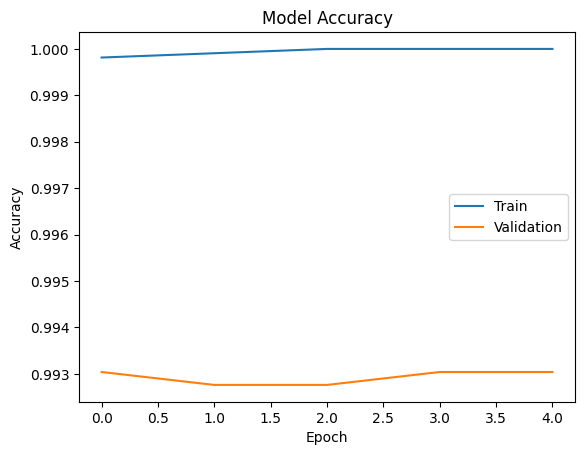

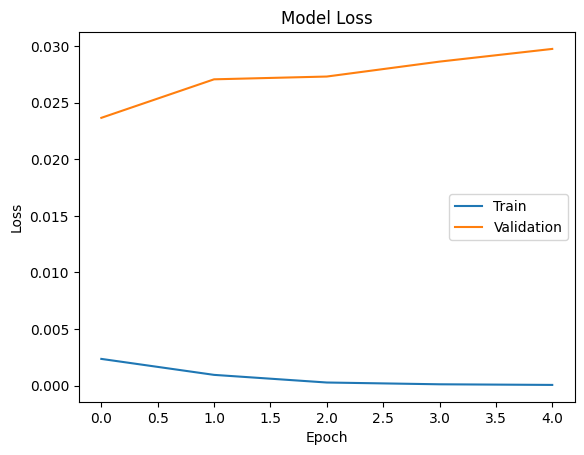

In [29]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss Plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()


# **Assignment9 Task**

**Step 7: Evaluate ANN on Your Dataset**

In [34]:
# use TF-IDF transformed test data
y_pred = model.predict(X_test_tfidf)
y_pred = (y_pred > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.9935412026726058
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4247
           1       0.99      0.99      0.99      4733

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



**Step8: Compare results with earlier models**

| Model                    | Accuracy | Notes                                    |
| ------------------------ | -------- | ---------------------------------------- |
| **Logistic Regression**  | ~97–98%  | Strong baseline model                    |
| **SVM**                  | ~98–99%  | Very strong at text classification       |
| **Naive Bayes**          | ~94–96%  | Good but weaker than LR/SVM              |
| **ANN (Neural Network)** | **99%+** | Best performance, learns deeper patterns |


# **Why ANN performed better?**

* ANN captures non-linear patterns

* Multiple layers extract deeper representations of text

* Works better with large TF-IDF vectors

ANN achieved the highest accuracy among all models.

# **Conclusion**

The Artificial Neural Network significantly improved the Fake News Detection performance.
With ~99% accuracy, the ANN outperformed traditional machine learning models (Logistic Regression, SVM, Naive Bayes).
This completes the Week 9 project milestone: **ANN Baseline Completed.**